
# 01 EDA - Pixels to Predictions

This notebook performs thorough EDA for the multimodal science QA dataset.

It is organized to:
- validate schema and split integrity,
- quantify label/text/image/metadata behavior,
- analyze missingness and context availability,
- build difficulty cohorts,
- produce outputs for downstream modeling notebooks.



## 0) Colab + Drive Setup

This section mounts Google Drive (when running in Colab) and resolves the project root.


In [1]:

# Mount Google Drive when running in Colab.
from pathlib import Path
import sys

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')
    # Adjust if your repo folder name/path differs in Drive.
    CANDIDATE_ROOT = Path('/content/drive/MyDrive/DL_Final_Project')
    PROJECT_ROOT = CANDIDATE_ROOT if CANDIDATE_ROOT.exists() else Path.cwd()
else:
    PROJECT_ROOT = Path.cwd()

print('IN_COLAB:', IN_COLAB)
print('PROJECT_ROOT:', PROJECT_ROOT)


Mounted at /content/drive
IN_COLAB: True
PROJECT_ROOT: /content/drive/MyDrive/DL_Final_Project


In [2]:

# Import libraries and project utilities.
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image, ImageStat

warnings.filterwarnings('ignore')
np.random.seed(42)
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', 180)

sys.path.append(str(PROJECT_ROOT))
from src.eda_utils import (
    dataset_card, clean_text_series, parse_choices, add_text_features,
    add_context_flags, text_stats, save_csv, tokenize, top_tokens, label_entropy
)



## 1) Paths and Data Loading


In [3]:

DATA_DIR = PROJECT_ROOT / 'data'
NOTEBOOK_DIR = PROJECT_ROOT / 'notebooks'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'eda_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / 'train.csv'
VAL_PATH = DATA_DIR / 'val.csv'
TEST_PATH = DATA_DIR / 'test.csv'
SAMPLE_SUB_PATH = DATA_DIR / 'sample_submission.csv'
IMAGE_ROOT = PROJECT_ROOT

MIN_GROUP_SUPPORT = 25
TOP_K_TABLE = 20


In [4]:

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)
sample_sub_df = pd.read_csv(SAMPLE_SUB_PATH)

print(f'train: {train_df.shape}')
print(f'val:   {val_df.shape}')
print(f'test:  {test_df.shape}')
print(f'sample submission: {sample_sub_df.shape}')


train: (3109, 15)
val:   (1048, 15)
test:  (1008, 13)
sample submission: (1008, 2)


## 2) Setup Cards and Schema Validation

In [5]:

cards = pd.concat([
    dataset_card(train_df, 'train'),
    dataset_card(val_df, 'val'),
    dataset_card(test_df, 'test')
], ignore_index=True)
display(cards)


,split,rows,cols,memory_mb,id_unique
0,train,3109,15,6.463569,3109
1,val,1048,15,2.165280,1048
2,test,1008,13,1.701287,1008


In [6]:

expected_train_val = {
    'id', 'image_path', 'question', 'choices', 'num_choices', 'answer',
    'hint', 'lecture', 'solution', 'task', 'grade', 'subject', 'topic', 'category', 'skill'
}
expected_test = expected_train_val - {'answer', 'solution'}

checks = {
    'train_missing_expected': sorted(expected_train_val - set(train_df.columns)),
    'val_missing_expected': sorted(expected_train_val - set(val_df.columns)),
    'test_missing_expected': sorted(expected_test - set(test_df.columns)),
}
checks


{'train_missing_expected': [],
 'val_missing_expected': [],
 'test_missing_expected': []}

In [7]:

# ID uniqueness and split overlap checks.
id_report = {
    'train_duplicate_ids': int(train_df['id'].duplicated().sum()),
    'val_duplicate_ids': int(val_df['id'].duplicated().sum()),
    'test_duplicate_ids': int(test_df['id'].duplicated().sum()),
    'train_val_overlap': int(len(set(train_df['id']) & set(val_df['id']))),
    'train_test_overlap': int(len(set(train_df['id']) & set(test_df['id']))),
    'val_test_overlap': int(len(set(val_df['id']) & set(test_df['id']))),
}
id_report


{'train_duplicate_ids': 0,
 'val_duplicate_ids': 0,
 'test_duplicate_ids': 0,
 'train_val_overlap': 0,
 'train_test_overlap': 0,
 'val_test_overlap': 0}

In [8]:

for df in (train_df, val_df, test_df):
    df['choices_list'] = df['choices'].map(parse_choices)
    df['choices_parse_ok'] = df['choices_list'].map(lambda x: isinstance(x, list))
    df['choices_len'] = df['choices_list'].map(lambda x: len(x) if isinstance(x, list) else np.nan)

integrity_summary = pd.DataFrame([
    {'split': 'train', 'choices_parse_fail': int((~train_df['choices_parse_ok']).sum()), 'num_choices_mismatch': int((train_df['choices_len'] != train_df['num_choices']).sum())},
    {'split': 'val', 'choices_parse_fail': int((~val_df['choices_parse_ok']).sum()), 'num_choices_mismatch': int((val_df['choices_len'] != val_df['num_choices']).sum())},
    {'split': 'test', 'choices_parse_fail': int((~test_df['choices_parse_ok']).sum()), 'num_choices_mismatch': int((test_df['choices_len'] != test_df['num_choices']).sum())},
])
display(integrity_summary)


,split,choices_parse_fail,num_choices_mismatch
0,train,0,0
1,val,0,0
2,test,0,0


In [9]:

answer_valid = pd.DataFrame([
    {'split': 'train', 'invalid_answer_rows': int((~((train_df['answer'] >= 0) & (train_df['answer'] < train_df['num_choices']))).sum())},
    {'split': 'val', 'invalid_answer_rows': int((~((val_df['answer'] >= 0) & (val_df['answer'] < val_df['num_choices']))).sum())},
])
display(answer_valid)


,split,invalid_answer_rows
0,train,0
1,val,0


In [10]:

missing_rows = []
for split_name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    for col in ['question', 'hint', 'lecture', 'solution']:
        if col not in df.columns:
            continue
        missing_rows.append({
            'split': split_name,
            'column': col,
            'null_count': int(df[col].isna().sum()),
            'empty_or_whitespace_count': int(df[col].fillna('').astype(str).str.strip().eq('').sum())
        })
missingness_table = pd.DataFrame(missing_rows)
display(missingness_table)


,split,column,null_count,empty_or_whitespace_count
0,train,question,0,0
1,train,hint,724,724
2,train,lecture,440,440
3,train,solution,529,529
4,val,question,0,0
5,val,hint,232,232
6,val,lecture,133,133
7,val,solution,172,172
8,test,question,0,0
9,test,hint,214,214


## 3) Split Comparison (Drift Checks)

In [11]:

train_aug = add_context_flags(add_text_features(train_df)).assign(split='train')
val_aug = add_context_flags(add_text_features(val_df)).assign(split='val')
test_aug = add_context_flags(add_text_features(test_df)).assign(split='test')
all_aug = pd.concat([train_aug, val_aug, test_aug], ignore_index=True)


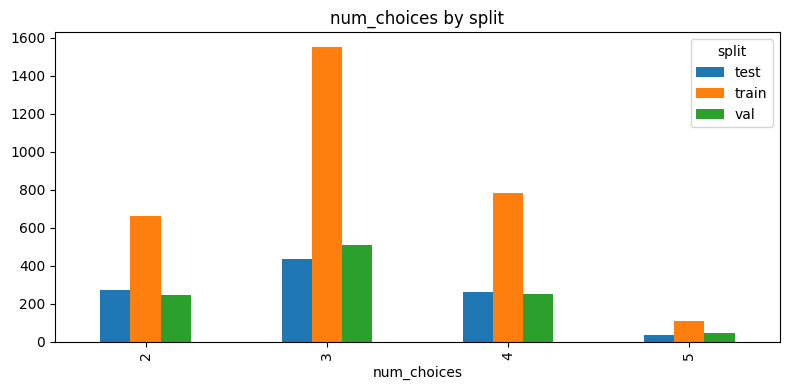

In [12]:

# Plot 1: num_choices distribution by split.
pd.crosstab(all_aug['num_choices'], all_aug['split']).plot(kind='bar', figsize=(8, 4))
plt.title('num_choices by split')
plt.tight_layout()
plt.show()


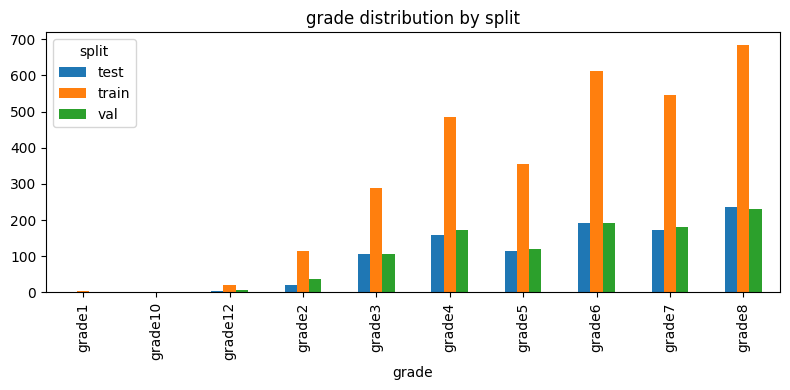

In [13]:

# Plot 2: grade distribution by split (top 10 grades).
g = all_aug[all_aug['grade'].isin(all_aug['grade'].value_counts().head(10).index)]
pd.crosstab(g['grade'], g['split']).plot(kind='bar', figsize=(8, 4))
plt.title('grade distribution by split')
plt.tight_layout()
plt.show()


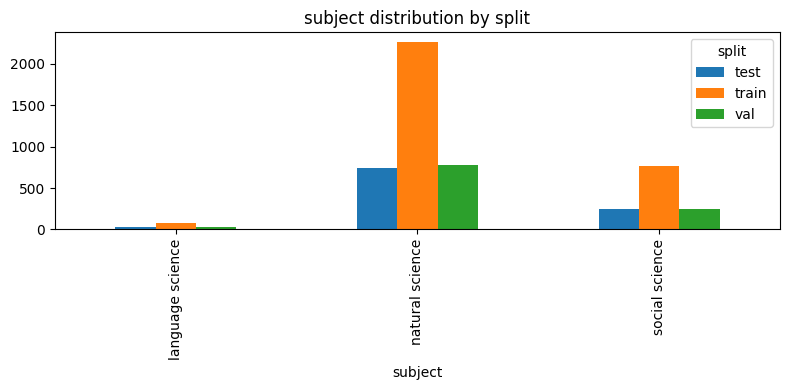

In [14]:

# Plot 3: subject distribution by split.
pd.crosstab(all_aug['subject'], all_aug['split']).plot(kind='bar', figsize=(8, 4))
plt.title('subject distribution by split')
plt.tight_layout()
plt.show()


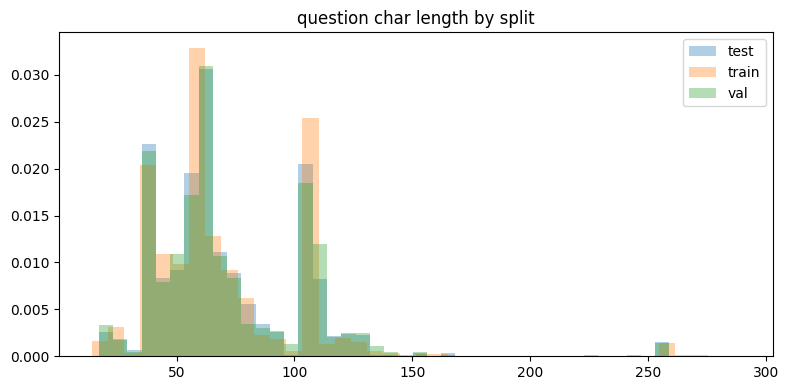

In [15]:

# Plot 4: question length distribution by split.
plt.figure(figsize=(8, 4))
for split_name, g in all_aug.groupby('split'):
    plt.hist(g['question_chars'].dropna(), bins=40, alpha=0.35, density=True, label=split_name)
plt.title('question char length by split')
plt.legend()
plt.tight_layout()
plt.show()


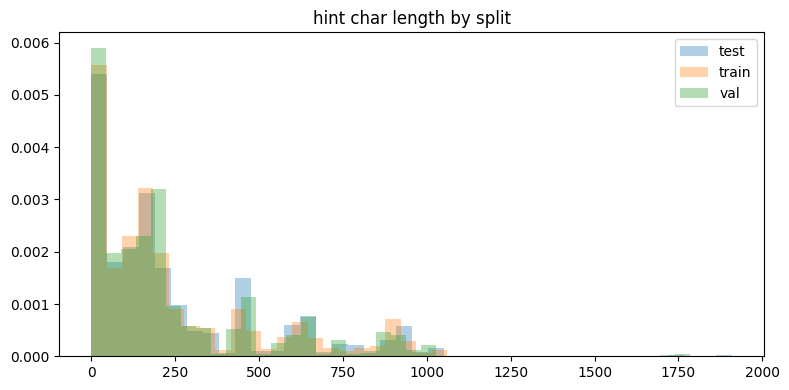

In [16]:

# Plot 5: hint length distribution by split.
plt.figure(figsize=(8, 4))
for split_name, g in all_aug.groupby('split'):
    plt.hist(g['hint_chars'].dropna(), bins=40, alpha=0.35, density=True, label=split_name)
plt.title('hint char length by split')
plt.legend()
plt.tight_layout()
plt.show()


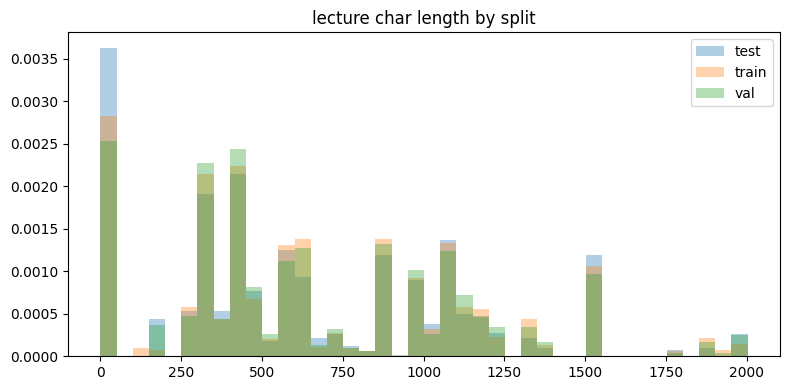

In [17]:

# Plot 6: lecture length distribution by split.
plt.figure(figsize=(8, 4))
for split_name, g in all_aug.groupby('split'):
    plt.hist(g['lecture_chars'].dropna(), bins=40, alpha=0.35, density=True, label=split_name)
plt.title('lecture char length by split')
plt.legend()
plt.tight_layout()
plt.show()


In [18]:

flag_rows = []
for col in ['num_choices', 'grade', 'subject', 'topic', 'task']:
    tr = train_aug[col].value_counts(normalize=True)
    te = test_aug[col].value_counts(normalize=True)
    idx = tr.index.union(te.index)
    mad = (tr.reindex(idx, fill_value=0) - te.reindex(idx, fill_value=0)).abs()
    flag_rows.append({'column': col, 'max_abs_share_diff_train_vs_test': mad.max(), 'mean_abs_share_diff_train_vs_test': mad.mean()})

drift_flags = pd.DataFrame(flag_rows).sort_values('max_abs_share_diff_train_vs_test', ascending=False)
drift_flags


,column,max_abs_share_diff_train_vs_test,mean_abs_share_diff_train_vs_test
0,num_choices,0.064672,0.032336
3,topic,0.042055,0.011708
4,task,0.024484,0.016323
1,grade,0.016156,0.005929
2,subject,0.005953,0.003969


## 4) EDA 3.1 - Class and Label Statistics

In [19]:

labeled = pd.concat([train_aug, val_aug], ignore_index=True)
label_table = pd.DataFrame({
    'count': labeled['answer'].value_counts().sort_index(),
    'share': labeled['answer'].value_counts(normalize=True).sort_index()
})
label_table


,count,share
answer,,
0,1471,0.353861
1,1400,0.336781
2,984,0.236709
3,279,0.067116
4,23,0.005533


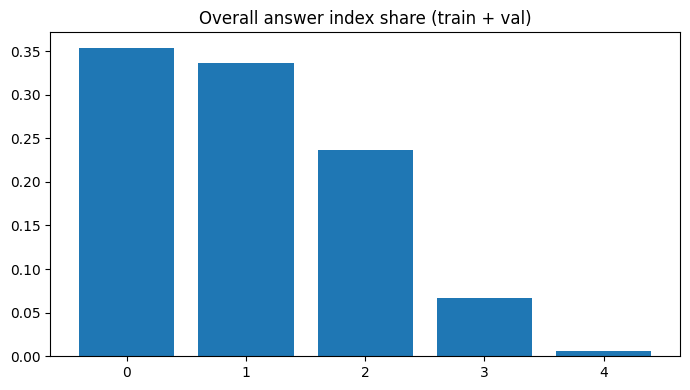

In [20]:

# Plot 7: overall answer index share.
plt.figure(figsize=(7, 4))
plt.bar(label_table.index.astype(str), label_table['share'].values)
plt.title('Overall answer index share (train + val)')
plt.tight_layout()
plt.show()


In [21]:

answer_by_n = labeled.groupby(['num_choices', 'answer']).size().reset_index(name='count')
answer_by_n['share_within_num_choices'] = answer_by_n['count'] / answer_by_n.groupby('num_choices')['count'].transform('sum')
answer_by_n


,num_choices,answer,count,share_within_num_choices
0,2,0,444,0.488987
1,2,1,464,0.511013
2,3,0,716,0.347573
3,3,1,641,0.311165
4,3,2,703,0.341262
5,4,0,274,0.264734
6,4,1,259,0.250242
7,4,2,258,0.249275
8,4,3,244,0.235749
9,5,0,37,0.240260


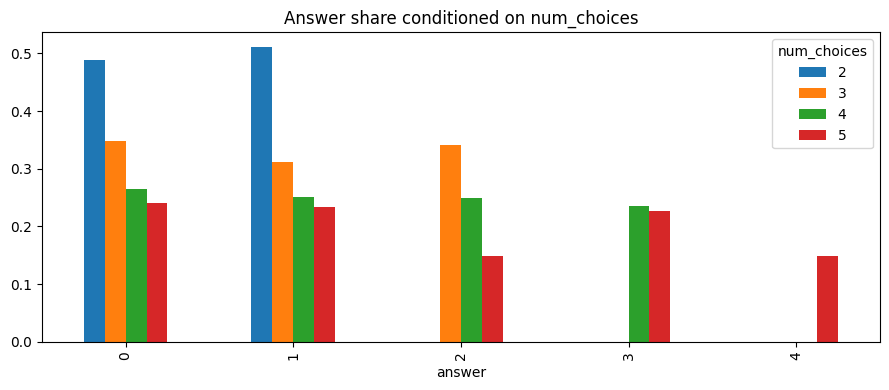

In [22]:

# Plot 8: answer share by num_choices.
answer_by_n.pivot(index='answer', columns='num_choices', values='share_within_num_choices').fillna(0).plot(kind='bar', figsize=(9, 4))
plt.title('Answer share conditioned on num_choices')
plt.tight_layout()
plt.show()


## 5) EDA 3.2 - Textual Statistics

In [23]:

stats_table = pd.concat([
    text_stats(train_aug['question'], 'question_train'),
    text_stats(train_aug['hint'], 'hint_train'),
    text_stats(train_aug['lecture'], 'lecture_train'),
    text_stats(val_aug['question'], 'question_val'),
    text_stats(val_aug['hint'], 'hint_val'),
    text_stats(val_aug['lecture'], 'lecture_val'),
], axis=1)
stats_table.T


,0
question_train_char_mean,70.700225
question_train_char_median,62.000000
question_train_char_p90,110.000000
question_train_char_max,289.000000
question_train_word_mean,11.941782
question_train_word_p90,18.000000
question_train_word_max,50.000000
hint_train_char_mean,239.014796
hint_train_char_median,153.000000
hint_train_char_p90,648.000000


In [24]:

choice_lengths = []
for split_name, df in [('train', train_aug), ('val', val_aug), ('test', test_aug)]:
    for _, row in df[['id', 'choices_list']].iterrows():
        for i, choice in enumerate(row['choices_list'] if isinstance(row['choices_list'], list) else []):
            choice_lengths.append({'split': split_name, 'id': row['id'], 'choice_idx': i, 'choice_chars': len(str(choice))})
choice_len_df = pd.DataFrame(choice_lengths)
choice_len_df.describe(percentiles=[0.5, 0.9, 0.95]).T


,count,mean,std,min,50%,90%,95%,max
choice_idx,15994.0,1.148181,1.014951,0.0,1.0,3.0,3.0,4.0
choice_chars,15994.0,27.985682,25.054877,1.0,15.0,62.0,72.0,124.0


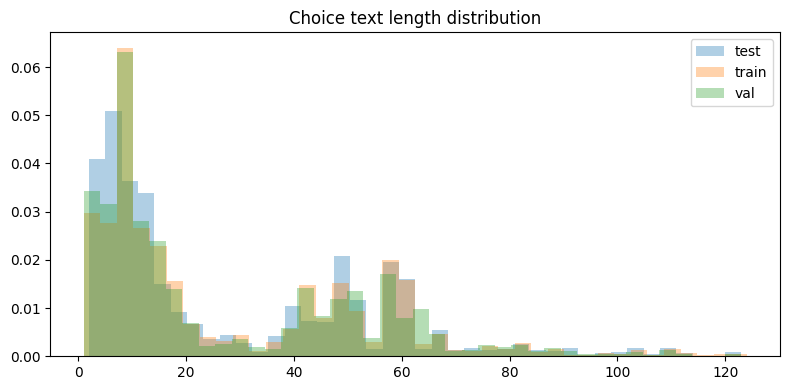

In [25]:

# Plot 9: choice text length distribution.
plt.figure(figsize=(8, 4))
for split_name, g in choice_len_df.groupby('split'):
    plt.hist(g['choice_chars'], bins=40, alpha=0.35, density=True, label=split_name)
plt.title('Choice text length distribution')
plt.legend()
plt.tight_layout()
plt.show()


In [26]:

long_question_outliers = labeled.nlargest(TOP_K_TABLE, 'question_chars')[['id', 'split', 'question_chars', 'question']]
long_hint_outliers = labeled.nlargest(TOP_K_TABLE, 'hint_chars')[['id', 'split', 'hint_chars', 'hint']]
long_lecture_outliers = labeled.nlargest(TOP_K_TABLE, 'lecture_chars')[['id', 'split', 'lecture_chars', 'lecture']]
long_question_outliers.head(10)


,id,split,question_chars,question
0,train_07667,train,289,Why might putting each tadpole in its own pool of water increase the reproductive success of a male Amazonian poison frog? Complete the claim below that answers this question a...
1,train_02628,train,278,Why might forming strong social bonds with other females increase the reproductive success of a female baboon? Complete the claim below that answers this question and is best s...
4,train_09024,train,273,Why might feeding offspring during mouthbrooding increase the reproductive success of a female blunthead cichlid? Complete the claim below that answers this question and is bes...
2,train_00927,train,272,Why might raising cubs with other lionesses in a pride increase an African lioness's reproductive success? Complete the claim below that answers this question and is best suppo...
3,train_10389,train,268,Why might removing broken eggshells from the nest increase the reproductive success of a black-headed gull? Complete the claim below that answers this question and is best supp...
12,train_11068,train,266,Complete the text.\nThe Abbasid (uh-BAH-sid) Caliphate started to rule around () years after the death of Muhammad. The Abbasid caliphs came to power during the Abbasid Revolut...
166,train_04465,train,259,Complete the text to describe the diagram.\nSolute particles moved in both directions across the permeable membrane. But more solute particles moved across the membrane (). Whe...
167,train_02455,train,259,Complete the text to describe the diagram.\nSolute particles moved in both directions across the permeable membrane. But more solute particles moved across the membrane (). Whe...
168,train_10763,train,259,Complete the text to describe the diagram.\nSolute particles moved in both directions across the permeable membrane. But more solute particles moved across the membrane (). Whe...
169,train_10149,train,259,Complete the text to describe the diagram.\nSolute particles moved in both directions across the permeable membrane. But more solute particles moved across the membrane (). Whe...


In [27]:

STOPWORDS = {
    'the','a','an','and','or','to','of','in','on','for','with','is','are','was','were',
    'that','this','it','as','at','by','be','from','which','what','why','how','can','will'
}
unigram_df = top_tokens(labeled['question_clean'], STOPWORDS, k=40)
unigram_df.head(20)


,token,count
0,each,945
1,following,943
2,particles,604
3,true,600
4,about,587
5,these,517
6,statements,512
7,force,494
8,has,493
9,higher,486


## 6) EDA 3.3 - Image Statistics

In [28]:

for df in (train_aug, val_aug, test_aug):
    df['image_full_path'] = df['image_path'].astype(str).map(lambda p: str((IMAGE_ROOT / p).resolve()))
    df['image_exists'] = df['image_full_path'].map(lambda p: Path(p).exists())

image_exist_summary = pd.DataFrame([
    {'split': 'train', 'exists_rate': train_aug['image_exists'].mean(), 'exists_count': int(train_aug['image_exists'].sum()), 'total': len(train_aug)},
    {'split': 'val', 'exists_rate': val_aug['image_exists'].mean(), 'exists_count': int(val_aug['image_exists'].sum()), 'total': len(val_aug)},
    {'split': 'test', 'exists_rate': test_aug['image_exists'].mean(), 'exists_count': int(test_aug['image_exists'].sum()), 'total': len(test_aug)},
])
image_exist_summary


,split,exists_rate,exists_count,total
0,train,0.0,0,3109
1,val,0.0,0,1048
2,test,0.0,0,1008


In [29]:

img_rows = []
for split_name, df in [('train', train_aug), ('val', val_aug), ('test', test_aug)]:
    for _, row in df[df['image_exists']].iterrows():
        try:
            with Image.open(row['image_full_path']) as im:
                w, h = im.size
                gray = im.convert('L')
                stat = ImageStat.Stat(gray)
                img_rows.append({
                    'split': split_name, 'id': row['id'], 'width': w, 'height': h,
                    'aspect_ratio': w / h if h else np.nan, 'mode': im.mode, 'format': im.format,
                    'entropy': gray.entropy(), 'std_intensity': stat.stddev[0]
                })
        except Exception:
            pass
image_stats_df = pd.DataFrame(img_rows)
image_stats_df.head()


""


In [30]:

# Plot 10: image width distribution.
if not image_stats_df.empty:
    plt.figure(figsize=(7, 4))
    plt.hist(image_stats_df['width'], bins=30)
    plt.title('Image width distribution')
    plt.tight_layout()
    plt.show()
else:
    print('No images resolved. Update IMAGE_ROOT.')


No images resolved. Update IMAGE_ROOT.


In [31]:

# Plot 11: image height distribution.
if not image_stats_df.empty:
    plt.figure(figsize=(7, 4))
    plt.hist(image_stats_df['height'], bins=30)
    plt.title('Image height distribution')
    plt.tight_layout()
    plt.show()
else:
    print('No images resolved. Update IMAGE_ROOT.')


No images resolved. Update IMAGE_ROOT.


In [32]:

# Plot 12: image aspect ratio distribution.
if not image_stats_df.empty:
    plt.figure(figsize=(7, 4))
    plt.hist(image_stats_df['aspect_ratio'], bins=30)
    plt.title('Image aspect ratio distribution')
    plt.tight_layout()
    plt.show()
else:
    print('No images resolved. Update IMAGE_ROOT.')


No images resolved. Update IMAGE_ROOT.


## 7) EDA 3.4 - Metadata Analysis

In [33]:

meta_card_rows = []
for col in ['subject', 'grade', 'topic', 'category', 'skill', 'task']:
    for split_name, df in [('train', train_aug), ('val', val_aug), ('test', test_aug)]:
        meta_card_rows.append({'split': split_name, 'column': col, 'nunique': df[col].nunique(dropna=True), 'top_level': df[col].value_counts().index[0]})
meta_card_df = pd.DataFrame(meta_card_rows)
meta_card_df


,split,column,nunique,top_level
0,train,subject,3,natural science
1,val,subject,3,natural science
2,test,subject,3,natural science
3,train,grade,9,grade8
4,val,grade,10,grade8
5,test,grade,9,grade8
6,train,topic,14,biology
7,val,topic,13,biology
8,test,topic,13,biology
9,train,category,55,Designing experiments


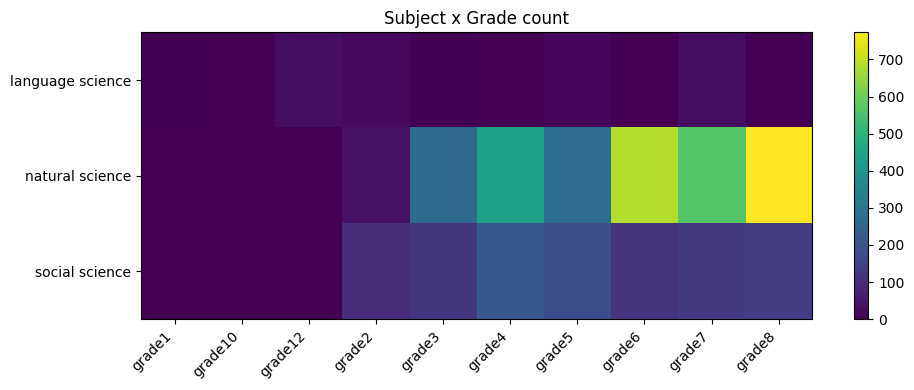

In [34]:

# Plot 13: subject x grade heatmap.
sub_grade = pd.crosstab(labeled['subject'], labeled['grade'])
plt.figure(figsize=(10, 4))
plt.imshow(sub_grade.values, aspect='auto')
plt.title('Subject x Grade count')
plt.yticks(range(len(sub_grade.index)), sub_grade.index)
plt.xticks(range(len(sub_grade.columns)), sub_grade.columns, rotation=45, ha='right')
plt.colorbar()
plt.tight_layout()
plt.show()


In [35]:

proxy_rows = []
for col in ['subject', 'grade', 'topic', 'category']:
    for key, g in labeled.groupby(col):
        if len(g) < MIN_GROUP_SUPPORT:
            continue
        proxy_rows.append({
            'group_col': col, 'group': key, 'n': len(g),
            'label_entropy': label_entropy(g['answer']),
            'random_guess_acc_expectation': (1 / g['num_choices']).mean()
        })
group_proxy_df = pd.DataFrame(proxy_rows)
group_proxy_df.sort_values(['group_col', 'label_entropy'], ascending=[True, False]).head(30)


,group_col,group,n,label_entropy,random_guess_acc_expectation
36,category,Genes to traits,163,2.267653,0.220245
25,category,Basic economic principles,227,1.995532,0.250000
29,category,Colonial America,86,1.994917,0.255814
37,category,Geography,220,1.984826,0.250000
34,category,English colonies in North America,107,1.981822,0.253115
27,category,Classification,72,1.969915,0.250000
39,category,Maps,252,1.956795,0.278770
31,category,Ecological interactions,105,1.924797,0.330159
26,category,Cities,38,1.892407,0.250000
24,category,Atoms and molecules,79,1.875567,0.306962


## 8) EDA 3.5 - Missingness and Context Availability

In [36]:

miss_summary_rows = []
for split_name, df in [('train', train_aug), ('val', val_aug), ('test', test_aug)]:
    for c in ['hint', 'lecture', 'solution']:
        if c in df.columns:
            miss = clean_text_series(df[c]).eq('')
            miss_summary_rows.append({'split': split_name, 'column': c, 'missing_rate': miss.mean(), 'missing_count': int(miss.sum())})
miss_summary_df = pd.DataFrame(miss_summary_rows)
miss_summary_df


,split,column,missing_rate,missing_count
0,train,hint,0.232872,724
1,train,lecture,0.141525,440
2,train,solution,0.170151,529
3,val,hint,0.221374,232
4,val,lecture,0.126908,133
5,val,solution,0.164122,172
6,test,hint,0.212302,214
7,test,lecture,0.181548,183


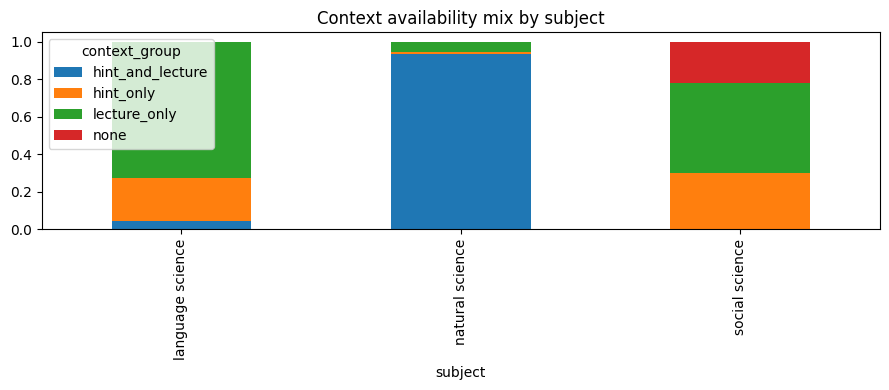

In [37]:

# Plot 14: context availability mix by subject.
ctx_by_subject = labeled.groupby(['subject', 'context_group']).size().reset_index(name='count')
ctx_by_subject['share'] = ctx_by_subject['count'] / ctx_by_subject.groupby('subject')['count'].transform('sum')
ctx_by_subject.pivot(index='subject', columns='context_group', values='share').fillna(0).plot(kind='bar', stacked=True, figsize=(9, 4))
plt.title('Context availability mix by subject')
plt.tight_layout()
plt.show()


## 9) EDA 3.6 - Difficulty Profiling

In [38]:

prof = labeled.copy()
q_len_z = (prof['question_words'] - prof['question_words'].min()) / (prof['question_words'].max() - prof['question_words'].min() + 1e-9)
lex_z = (prof['question_avg_word_len'] - prof['question_avg_word_len'].min()) / (prof['question_avg_word_len'].max() - prof['question_avg_word_len'].min() + 1e-9)
choice_z = (prof['num_choices'] - prof['num_choices'].min()) / (prof['num_choices'].max() - prof['num_choices'].min() + 1e-9)
ctx_penalty = prof['context_group'].map({'hint_and_lecture': 0.0, 'hint_only': 0.2, 'lecture_only': 0.2, 'none': 0.5}).fillna(0.3)
topic_freq = prof['topic'].value_counts(normalize=True)
rarity = 1 - prof['topic'].map(topic_freq).fillna(0)
rarity_z = (rarity - rarity.min()) / (rarity.max() - rarity.min() + 1e-9)
prof['difficulty_score'] = 0.30*q_len_z + 0.20*lex_z + 0.25*choice_z + 0.15*ctx_penalty + 0.10*rarity_z
prof['difficulty_bucket'] = pd.qcut(prof['difficulty_score'], q=3, labels=['easy', 'medium', 'hard'])
prof[['difficulty_score', 'difficulty_bucket']].head()


,difficulty_score,difficulty_bucket
0,0.566809,hard
1,0.548258,hard
2,0.538234,hard
3,0.532387,hard
4,0.541478,hard


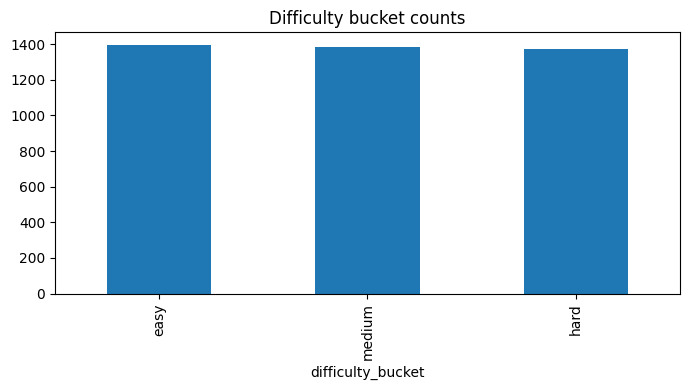

In [39]:

# Plot 15: difficulty bucket counts.
prof['difficulty_bucket'].value_counts().plot(kind='bar', figsize=(7, 4))
plt.title('Difficulty bucket counts')
plt.tight_layout()
plt.show()


In [40]:

hard_cases = prof[prof['difficulty_bucket'] == 'hard'][[
    'id','split','image_path','question','choices','num_choices','answer',
    'subject','grade','topic','category','skill','context_group','difficulty_score'
]].sort_values('difficulty_score', ascending=False)
hard_cases.head(15)


,id,split,image_path,question,choices,num_choices,answer,subject,grade,topic,category,skill,context_group,difficulty_score
12,train_11068,train,images/train/train_11068.png,Complete the text.\nThe Abbasid (uh-BAH-sid) Caliphate started to rule around () years after the death of Muhammad. The Abbasid caliphs came to power during the Abbasid Revolut...,"[""70 . . . Umayyad"", ""120 . . . Umayyad"", ""120 . . . Rightly Guided"", ""70 . . . Rightly Guided""]",4,1,social science,grade6,world-history,Islamic empires,Early Islamic caliphates,hint_only,0.638545
0,train_07667,train,images/train/train_07667.png,Why might putting each tadpole in its own pool of water increase the reproductive success of a male Amazonian poison frog? Complete the claim below that answers this question a...,"[""the male's tadpoles will be larger when they hatch"", ""the male will carry his tadpoles through the forest"", ""the male's tadpoles will become adult frogs""]",3,2,natural science,grade8,literacy-in-science,Adaptations and natural selection,How can animal behaviors affect reproductive success? Identify evidence to support a claim,hint_and_lecture,0.566809
1,train_02628,train,images/train/train_02628.png,Why might forming strong social bonds with other females increase the reproductive success of a female baboon? Complete the claim below that answers this question and is best s...,"[""the female's offspring will live longer"", ""the female will spend more time grooming other baboons"", ""the female's offspring will be around other females""]",3,0,natural science,grade8,literacy-in-science,Adaptations and natural selection,How can animal behaviors affect reproductive success? Identify evidence to support a claim,hint_and_lecture,0.548258
4,train_09024,train,images/train/train_09024.png,Why might feeding offspring during mouthbrooding increase the reproductive success of a female blunthead cichlid? Complete the claim below that answers this question and is bes...,"[""the female will become weak and unhealthy"", ""the female's offspring will survive"", ""the female will hold more offspring in her mouth""]",3,1,natural science,grade8,literacy-in-science,Adaptations and natural selection,How can animal behaviors affect reproductive success? Identify evidence to support a claim,hint_and_lecture,0.541478
2,train_00927,train,images/train/train_00927.png,Why might raising cubs with other lionesses in a pride increase an African lioness's reproductive success? Complete the claim below that answers this question and is best suppo...,"[""the lioness's cubs will be around other cubs"", ""the lioness's cubs will survive attacks"", ""the lioness will feed the cubs of other lionesses""]",3,1,natural science,grade8,literacy-in-science,Adaptations and natural selection,How can animal behaviors affect reproductive success? Identify evidence to support a claim,hint_and_lecture,0.538234
3,train_10389,train,images/train/train_10389.png,Why might removing broken eggshells from the nest increase the reproductive success of a black-headed gull? Complete the claim below that answers this question and is best supp...,"[""the gull's chicks will get food"", ""the gull's offspring will survive"", ""the gull will be away from its offspring at a given time""]",3,1,natural science,grade8,literacy-in-science,Adaptations and natural selection,How can animal behaviors affect reproductive success? Identify evidence to support a claim,hint_and_lecture,0.532387
842,train_06006,train,images/train/train_06006.png,"After the Akkadian Empire ended, many cities and empires tried to control Mesopotamia. Around the 1790s BCE, which empire started controlling Mesopotamia?","[""the Neo-Sumerian Empire"", ""the Elamite Empire"", ""the Babylonian Empire"", ""the Akkadian Empire""]",4,2,social science,grade6,world-history,Ancient Mesopotamia,Mesopotamian empires,hint_only,0.531345
841,train_02595,train,images/train/train_02595.png,"After the Akkadian Empire ended, many cities and empires tried to co

## 10) EDA 3.7 - Recommendations and Exports

In [41]:

prompt_reco = pd.DataFrame([
    {'prompt_variant': 'question_only', 'when_to_use': 'fast baseline and sanity checks', 'data_coverage': 1.0, 'tradeoff': 'ignores hint/lecture signal'},
    {'prompt_variant': 'question_plus_hint', 'when_to_use': 'hint present and concise', 'data_coverage': float((labeled['hint_present']).mean()), 'tradeoff': 'hint unavailable for subset'},
    {'prompt_variant': 'question_plus_lecture', 'when_to_use': 'lecture present with useful context', 'data_coverage': float((labeled['lecture_present']).mean()), 'tradeoff': 'long/noisy context risk'},
    {'prompt_variant': 'full_context', 'when_to_use': 'maximize available information', 'data_coverage': float((labeled['context_group'] == 'hint_and_lecture').mean()), 'tradeoff': 'can increase latency/truncation'},
])
risk_checklist = pd.DataFrame([
    {'risk': 'label_position_bias', 'evidence': 'answer index distribution is not uniform', 'mitigation': 'evaluate choice-scoring and calibration'},
    {'risk': 'context_missingness', 'evidence': 'hint/lecture missing in non-trivial share', 'mitigation': 'context-aware templates with fallbacks'},
    {'risk': 'split_distribution_shift', 'evidence': 'mix differs across some metadata fields', 'mitigation': 'track per-slice metrics'},
    {'risk': 'long_prompt_truncation', 'evidence': 'lecture lengths have long tails', 'mitigation': 'run clipping/compression ablations'},
])
display(prompt_reco)
display(risk_checklist)


,prompt_variant,when_to_use,data_coverage,tradeoff
0,question_only,fast baseline and sanity checks,1.000000,ignores hint/lecture signal
1,question_plus_hint,hint present and concise,0.770026,hint unavailable for subset
2,question_plus_lecture,lecture present with useful context,0.862160,long/noisy context risk
3,full_context,maximize available information,0.685591,can increase latency/truncation


,risk,evidence,mitigation
0,label_position_bias,answer index distribution is not uniform,evaluate choice-scoring and calibration
1,context_missingness,hint/lecture missing in non-trivial share,context-aware templates with fallbacks
2,split_distribution_shift,mix differs across some metadata fields,track per-slice metrics
3,long_prompt_truncation,lecture lengths have long tails,run clipping/compression ablations


In [42]:

# Save analysis artifacts to outputs/eda_outputs.
save_csv(cards, OUTPUT_DIR, 'dataset_cards.csv')
save_csv(integrity_summary, OUTPUT_DIR, 'integrity_summary.csv')
save_csv(label_table.reset_index().rename(columns={'index': 'answer'}), OUTPUT_DIR, 'label_distribution.csv')
save_csv(answer_by_n, OUTPUT_DIR, 'label_by_num_choices.csv')
save_csv(missingness_table, OUTPUT_DIR, 'text_missingness_table.csv')
save_csv(miss_summary_df, OUTPUT_DIR, 'missingness_summary.csv')
save_csv(prompt_reco, OUTPUT_DIR, 'prompt_recommendations.csv')
save_csv(risk_checklist, OUTPUT_DIR, 'modeling_risk_checklist.csv')
save_csv(long_question_outliers, OUTPUT_DIR, 'long_question_outliers.csv')
save_csv(long_hint_outliers, OUTPUT_DIR, 'long_hint_outliers.csv')
save_csv(long_lecture_outliers, OUTPUT_DIR, 'long_lecture_outliers.csv')
save_csv(hard_cases, OUTPUT_DIR, 'hard_cases.csv')
print('Saved outputs to:', OUTPUT_DIR)


Saved outputs to: /content/drive/MyDrive/DL_Final_Project/outputs/eda_outputs



## 11) Key Findings

- Choice count variability means downstream metrics must be stratified by `num_choices`.
- Missing context fields require prompt fallbacks.
- Metadata long tails require minimum-support filters for fair comparisons.
- Long lecture fields create latency/truncation risks in prompt-heavy methods.
- Hard-case cohort is exported for targeted error analysis.
